In [2]:
import numpy as np

# 1. 创建形状为3×4的随机矩阵X，
X = np.random.randn(3, 4)
print("矩阵 X:")
print(X)

# 2. 创建形状为4×2的全1矩阵Y。
Y = np.ones((4, 2))
print("\n矩阵 Y:")
print(Y)

# 3. 计算Z = X × Y
Z = X @ Y
print("\n矩阵 Z (X × Y):")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及Z的第2行所有元素。
element_1_2 = Z[0, 1]
row_2 = Z[1, :]    
print(f"\n第一行和第二列交叉处的元素: {element_1_2}")
print(f"第2行所有元素: {row_2}")

# 5. 计算 Z 的 Frobenius 范数。
frobenius_norm_Z = np.linalg.norm(Z)
print(f"\nFrobenius 范数: {frobenius_norm_Z}")

矩阵 X:
[[-1.11410401 -1.13192183  1.48462308  2.89591179]
 [-0.68745461  0.47865631 -0.27910858 -0.13180182]
 [-1.18314433  0.5080362  -3.02521344  1.09637849]]

矩阵 Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z (X × Y):
[[ 2.13450903  2.13450903]
 [-0.61970869 -0.61970869]
 [-2.60394307 -2.60394307]]

第一行和第二列交叉处的元素: 2.1345090329586442
第2行所有元素: [-0.61970869 -0.61970869]

Frobenius 范数: 4.841629313778297


模拟得到的1000个均值的实际方差为: 0.000008


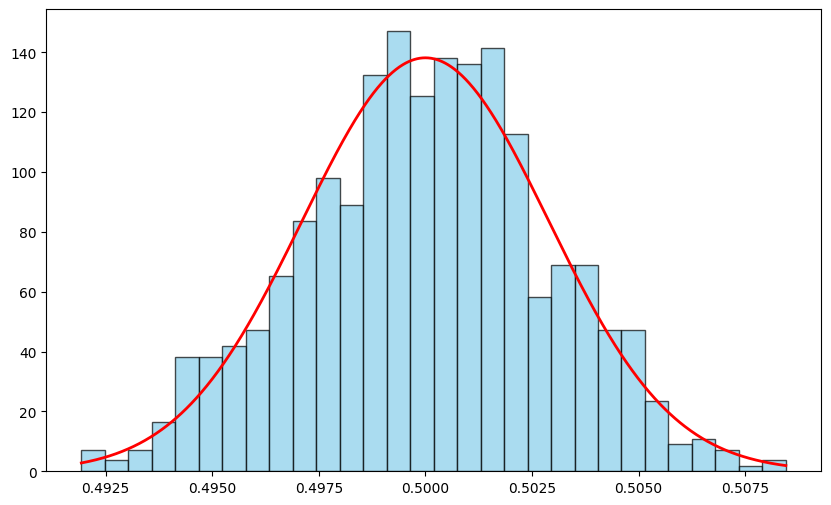

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 10000  # 每次抽取的样本数量
m = 1000   # 重复实验的次数
np.random.seed(42) 

sample_means = []
for _ in range(m):
    # 从 U(0,1) 中抽取 n 个样本
    samples = np.random.uniform(0, 1, n)
    # 计算这 n 个样本的均值
    mean_of_samples = np.mean(samples)
    sample_means.append(mean_of_samples)

sample_means = np.array(sample_means)

# 创建图形
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='模拟均值的分布')

mu_theoretical = 0.5
sigma_theoretical = np.sqrt(1/12) # 总体标准差
std_of_sample_means = sigma_theoretical / np.sqrt(n) # 样本均值的标准差

x = np.linspace(min(sample_means), max(sample_means), 1000)
y = stats.norm.pdf(x, mu_theoretical, std_of_sample_means)
plt.plot(x, y, 'r-', linewidth=2, label=f'理论正态分布 N({mu_theoretical}, {std_of_sample_means:.4f}²)')

actual_variance = np.var(sample_means)
print(f"模拟得到的1000个均值的实际方差为: {actual_variance:.6f}")

In [8]:
import torch

x = torch.tensor(2.0)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

a = x * w1      
b = a + w2      
L = b ** 2  

print(f"前向计算结果: L = {L.item()}")

a_val = x.item() * w1.item() 
b_val = a_val + w2.item()    

dL_db = 2 * b_val
dL_dw2_manual = dL_db * 1
dL_dw1_manual = dL_db * 1 * x.item()

print(f"手动计算的梯度 dL/dw1 = {dL_dw1_manual}")
print(f"手动计算的梯度 dL/dw2 = {dL_dw2_manual}")

L.backward()
dL_dw1_auto = w1.grad
dL_dw2_auto = w2.grad
print(f"自动微分的梯度 dL/dw1 = {dL_dw1_auto.item()}")
print(f"自动微分的梯度 dL/dw2 = {dL_dw2_auto.item()}")

if (abs(dL_dw1_manual - dL_dw1_auto.item()) < 1e-9 and 
    abs(dL_dw2_manual - dL_dw2_auto.item()) < 1e-9):
    print("手动计算与自动微分结果一致")
else:
    print("结果不一致")

前向计算结果: L = 12.25
手动计算的梯度 dL/dw1 = 14.0
手动计算的梯度 dL/dw2 = 7.0
自动微分的梯度 dL/dw1 = 14.0
自动微分的梯度 dL/dw2 = 7.0
手动计算与自动微分结果一致


In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

digits = load_digits()
X, y = digits.data, digits.target
y = y.reshape(-1, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 对标签进行 One-Hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

n_features = X_train.shape[1]     
n_classes = y_train_onehot.shape[1]

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"特征维度: {n_features}, 类别数量: {n_classes}")

# 权重 W 和偏置 b
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

def softmax(z):
   
   # axis=1, keepdims=True 确保减法是沿着每一行进行的
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
   
    n_samples = y_true.shape[0]
    # 为了避免 log(0) 导致 -inf，给 y_pred 加上一个极小值
    loss = -np.sum(y_true * np.log(y_pred + 1e-9)) / n_samples
    return loss

# 训练模型

learning_rate = 0.1
batch_size = 32
n_epochs = 50
n_train_samples = X_train.shape[0]

for epoch in range(n_epochs):
    # 每个 epoch 开始时，随机打乱数据
    permutation = np.random.permutation(n_train_samples)
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train_onehot[permutation]
    
    epoch_loss = 0.0
    n_batches = n_train_samples // batch_size
    
    for i in range(n_batches):
        # 获取一个小批量的数据
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        X_batch = X_train_shuffled[start_idx:end_idx]
        y_batch = y_train_shuffled[start_idx:end_idx]
        
        # 前向传播 
        # Z = XW + b
        Z = np.dot(X_batch, W) + b
        # A = softmax(Z)
        A = softmax(Z)
        
        # 计算当前批次的损失
        batch_loss = cross_entropy_loss(y_batch, A)
        epoch_loss += batch_loss
        
        # 反向传播

        # 计算梯度
        # dZ = (1/batch_size) * (A - y_batch)
        dZ = (A - y_batch) / batch_size
        # dW = X^T . dZ
        dW = np.dot(X_batch.T, dZ)
        # db = sum(dZ) 沿着样本轴求和
        db = np.sum(dZ, axis=0, keepdims=True)
        
        # 参数更新 
        W -= learning_rate * dW
        b -= learning_rate * db
        
    # 打印每个 epoch 的平均损失
    avg_loss = epoch_loss / n_batches
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

# 测试评估

Z_test = np.dot(X_test, W) + b
A_test = softmax(Z_test)

# 预测类别 (取概率最大的类别)
y_pred_classes = np.argmax(A_test, axis=1)
y_test_classes = np.argmax(y_test_onehot, axis=1)

# 计算准确率
accuracy = np.mean(y_pred_classes == y_test_classes)
print(f"测试集准确率: {accuracy * 100:.2f}%")

训练集大小: (1437, 64), 测试集大小: (360, 64)
特征维度: 64, 类别数量: 10
Epoch [1/50], Loss: 5.1188
Epoch [10/50], Loss: 0.4316
Epoch [20/50], Loss: 0.1317
Epoch [30/50], Loss: 0.0339
Epoch [40/50], Loss: 0.0387
Epoch [50/50], Loss: 0.0002
测试集准确率: 97.22%


迭代次数 200/1000, 损失: 0.1822
迭代次数 400/1000, 损失: 0.1749
迭代次数 600/1000, 损失: 0.1732
迭代次数 800/1000, 损失: 0.1727
迭代次数 1000/1000, 损失: 0.1725

测试集分类准确率: 94.00%


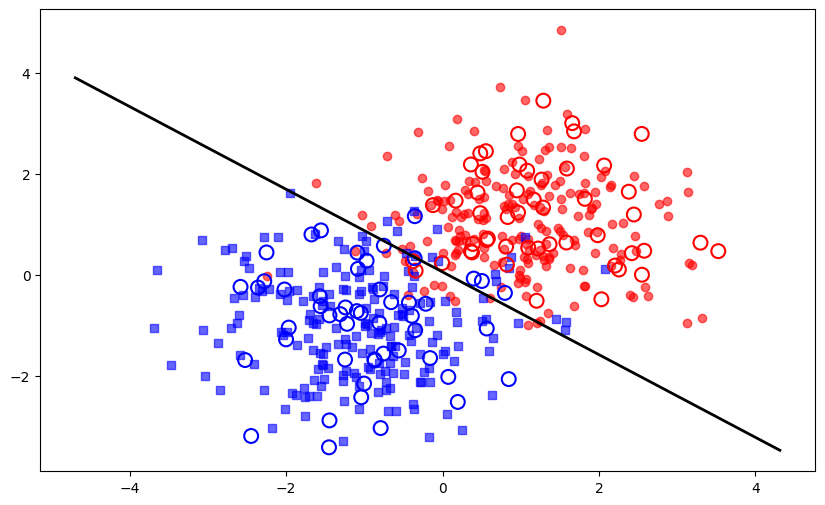

In [7]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

def generate_data(n_samples=200):
    # 生成类别 0 的数据: 均值为 [1, 1]
    class_0 = np.random.randn(n_samples, 2) + np.array([1, 1])
    label_0 = np.zeros((n_samples, 1))

    # 生成类别 1 的数据: 均值为 [-1, -1]
    class_1 = np.random.randn(n_samples, 2) + np.array([-1, -1])
    label_1 = np.ones((n_samples, 1))

    # 合并数据
    X = np.vstack((class_0, class_1))
    y = np.vstack((label_0, label_1))

    return X, y

X_train, y_train = generate_data(200)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m
    return loss

# 使用梯度下降法训练模型 
w = np.random.randn(2, 1)
b = 0.0
learning_rate = 0.1
iterations = 1000

# 记录损失用于观察收敛
loss_history = []

for i in range(iterations):
    # 前向传播
    # X_train shape: (400, 2), w shape: (2, 1) -> z shape: (400, 1)
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)

    # 计算损失
    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)

    # 计算梯度
    m = X_train.shape[0]
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / m
    db = np.sum(dz) / m

    # 更新参数
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # 每 200 次打印一次损失
    if (i+1) % 200 == 0:
        print(f"迭代次数 {i+1}/{iterations}, 损失: {loss:.4f}")

# 绘制决策边界并计算测试集准确率 

# 生成测试集
X_test, y_test = generate_data(50)

# 在测试集上进行预测
z_test = np.dot(X_test, w) + b
y_test_pred_prob = sigmoid(z_test)
y_test_pred_class = (y_test_pred_prob >= 0.5).astype(int)

# 计算准确率
accuracy = np.mean(y_test_pred_class == y_test) * 100
print(f"\n测试集分类准确率: {accuracy:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train.flatten()==0][:, 0], X_train[y_train.flatten()==0][:, 1],
            c='red', marker='o', label='训练集 类别 0', alpha=0.6)
plt.scatter(X_train[y_train.flatten()==1][:, 0], X_train[y_train.flatten()==1][:, 1],
            c='blue', marker='s', label='训练集 类别 1', alpha=0.6)

# 绘制决策边界
x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x1_range = np.linspace(x1_min, x1_max, 100)
if w[1] != 0:
    x2_boundary = -(w[0] * x1_range + b) / w[1]
    plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='决策边界')

plt.scatter(X_test[y_test.flatten()==0][:, 0], X_test[y_test.flatten()==0][:, 1],
            facecolors='none', edgecolors='red', s=100, linewidths=1.5, label='测试集 类别 0')
plt.scatter(X_test[y_test.flatten()==1][:, 0], X_test[y_test.flatten()==1][:, 1],
            facecolors='none', edgecolors='blue', s=100, linewidths=1.5, label='测试集 类别 1')


